In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [4]:
file_path="C:/Users/ADHITHYA/Downloads/archive/student_performance.csv"

In [5]:
data=pd.read_csv(file_path)

In [6]:
data.head()

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


In [7]:
data.shape

(500, 11)

In [8]:
print("Missing Values:\n",data.isnull().sum())

Missing Values:
 student_id                0
gender                    0
age                       0
study_hours_per_week      0
attendance_rate           0
parent_education        117
internet_access           0
extracurricular           0
previous_score            0
final_score               0
passed                    0
dtype: int64


In [9]:
print("Duplicate Values: \n",data.duplicated().value_counts())

Duplicate Values: 
 False    500
Name: count, dtype: int64


In [10]:
data=data.drop(columns=['student_id','parent_education','passed'])

In [16]:
le = LabelEncoder()

In [18]:
cat_cols = ['gender','internet_access', 'extracurricular']

for col in cat_cols:
    data[col] = le.fit_transform(data[col])

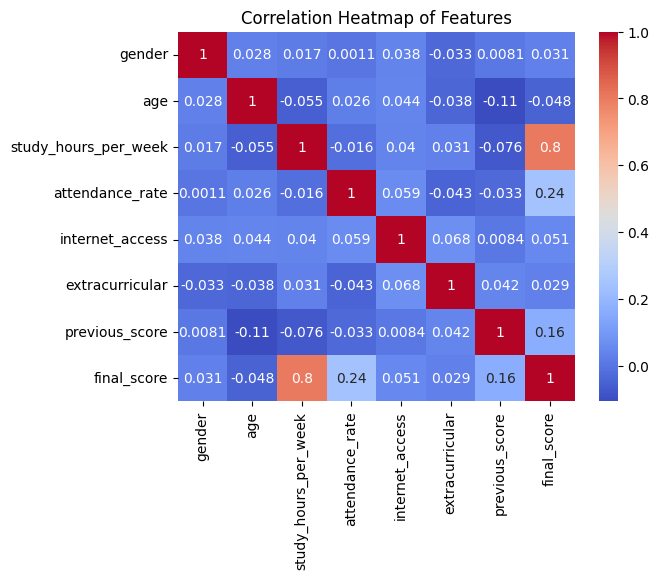

In [19]:
plt.Figure(figsize=(10,6))
sns.heatmap(data.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()

In [22]:
x = data.drop(columns=['final_score'])
y = data['final_score']

In [27]:
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=42)

In [31]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [32]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
y_pred = model.predict(x_test_scaled)

In [34]:
print("R2 Score :", r2_score(y_test, y_pred))
print("Mean Squared Error :", mean_squared_error(y_test, y_pred))

print("\nCoefficients:")
for col, coef in zip(x.columns, model.coef_):
    print(col, ":", coef)

R2 Score : 0.7515869668211548
Mean Squared Error : 53.92301711213193

Coefficients:
gender : 0.05845144215529507
age : 0.5386744264573036
study_hours_per_week : 12.807806892804626
attendance_rate : 4.001450782491909
internet_access : -0.001962796833493379
extracurricular : -0.03885550311043225
previous_score : 3.672331842722548


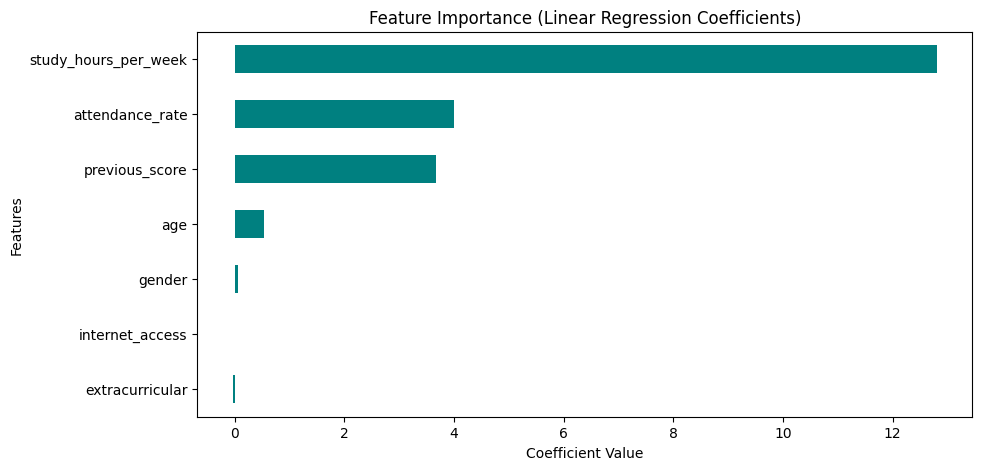

In [35]:
feature_importance=pd.Series(model.coef_,index=x.columns)
plt.figure(figsize=(10,5))
feature_importance.sort_values().plot(kind="barh",color="teal")
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()


In [40]:
sample_input=np.array([[0,20,5,77.0,1,1,34]])
sample_input_scaled=scaler.transform(sample_input)
predicted_value=model.predict(sample_input_scaled)[0]
print(f"Predicted mean final value:{predicted_value:.2f}")

Predicted mean final value:36.21


C:\Users\ADHITHYA\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [36]:
data.head()

,gender,age,study_hours_per_week,attendance_rate,internet_access,extracurricular,previous_score,final_score
0,1,15,25,63.8,1,1,41,67
1,0,15,2,54.7,1,1,83,28
2,0,19,10,90.5,1,0,73,49
3,1,16,26,66.8,0,1,75,70
4,0,15,25,73.0,0,1,67,77
